### Numpy VS Python list


In [ ]:
import numpy as np
import time

In [3]:
# Creating two list of 10*10^6 & 10*10^6 to 20^10^6 element and adding both ans storing in c

a=[i for i in range(10000000)]
b=[i for i in range(10000000,20000000)]

c=[]

start=time.time()

for i in range(len(a)):
    c.append(a[i]+b[i])

print(time.time()-start)



1.2200360298156738


In [4]:
# Creating a numpy for same operation
 
import numpy as np

a=np.arange(10000000)
b=np.arange(10000000,20000000)
start=time.time()
c=a+b
print(time.time()-start)

print(c)


0.0964810848236084
[10000000 10000002 10000004 ... 29999994 29999996 29999998]


In [16]:
1.191044569015503/0.0958871841430664

#numpy is usually 9.6 times faster then on this operation


12.421311353125466

## memory
#### checking memory of list vs numpy array

In [6]:
a =[i for i in range(10000000)]
import sys

size=sys.getsizeof(a)

print((size/1024)/1024)

84.96776580810547


In [22]:
a=np.arange(10000000)
size=sys.getsizeof(a)
print((size/1024)/1024)

76.29405212402344


# Advance Indexing
#### fancy and boolean 


In [54]:
#fancy

a=np.arange(12).reshape(4,3)
print(a)
a[[0,1,2,3],[0,1,2,1]] # passing a list [row,row],[col],[col] and then providing the index of row and column
#also row para and column para should be same

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


array([ 0,  4,  8, 10])

In [55]:
#boolean

a=np.random.randint(1,100,24).reshape(6,4)
print(a)

[[64 73  4 12]
 [43 44  2 24]
 [58 32 58 37]
 [61 75  5  2]
 [66 13 36 29]
 [33 24 31 78]]


In [56]:
#find all digit greater then 50
#we can use the boolean matrix as mask and remove the non required element
a>50

array([[ True,  True, False, False],
       [False, False, False, False],
       [ True, False,  True, False],
       [ True,  True, False, False],
       [ True, False, False, False],
       [False, False, False,  True]])

In [57]:
a[a>50]

array([64, 73, 58, 58, 61, 75, 66, 78], dtype=int32)

In [58]:
a % 2 == 0

array([[ True, False,  True,  True],
       [False,  True,  True,  True],
       [ True,  True,  True, False],
       [False, False, False,  True],
       [ True, False,  True, False],
       [False,  True, False,  True]])

In [59]:
a[a%2==0]

array([64,  4, 12, 44,  2, 24, 58, 32, 58,  2, 66, 36, 24, 78],
      dtype=int32)

In [60]:
(a>50) & (a%2==0)

array([[ True, False, False, False],
       [False, False, False, False],
       [ True, False,  True, False],
       [False, False, False, False],
       [ True, False, False, False],
       [False, False, False,  True]])

In [61]:
a[(a>50) & (a%2==0)]

array([64, 58, 58, 66, 78], dtype=int32)

# BROADCASTING
##### How numpy treats array with different shapes during airthmatic operation
##### Smaller array is broadcasted on large array so that it can be compatible in shape

### Rules of broadcasting

##### Rule 1 : Make both array of same number dimension( 2d-> (3,2) & 1d-> (2) change (2) to 2d -> (1,2) , add 1 to Head )

##### Rule 2 : Make each Dimension of the two arrays the same size
##### now we have (3,2) and (1,2) so change (1,2)-->(3,2) now both are same

##### Rule 3 : either of one array must have 1 or greater 

In [18]:
# example of different shape
print(np.arange(3))
print(np.arange(3)+5)


[0 1 2]
[5 6 7]


In [19]:
print(np.ones((3,3)))
print(np.arange(3))
print(np.ones((3,3))+np.arange(3))

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
[0 1 2]
[[1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]]


In [27]:
a=np.arange(3).reshape(1,3)
b=np.arange(3).reshape(3,1)

a+b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

In [29]:
a=np.arange(3).reshape(1,3)
b=np.arange(4).reshape(4,1)

print(a)
print(b)

a+b

[[0 1 2]]
[[0]
 [1]
 [2]
 [3]]


array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4],
       [3, 4, 5]])

In [38]:
# error case

try:
    a=np.arange(12).reshape(3,4)
    b=np.arange(3).reshape(3)

    a+b
except Exception as e:
    print("error",e)

error operands could not be broadcast together with shapes (3,4) (3,) 


In [43]:
try:
    a=np.arange(12).reshape(3,4)
    b=np.arange(2).reshape(2,1)

    print(a+b)
except Exception as e:
    print("error :",e)

error : operands could not be broadcast together with shapes (3,4) (2,1) 


## Working with Mathematical Formulas
#### Built in function 

In [45]:
a=np.arange(1234)
np.sum(a)

np.int64(760761)

In [46]:
np.sin(a)

array([ 0.        ,  0.84147098,  0.90929743, ..., -0.48321239,
        0.47562974,  0.99718008], shape=(1234,))

In [51]:
#sigmoid #used in logitic regression

# s(x)=1/1+e^-x

a=np.arange(10)

def sigmoid(array):
    return 1/(1+np.exp(-(array)))

sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661])

In [54]:
#mean squared error # used in loss function

#mes= 1/n i to n (original-result)^2

actual=np.random.randint(1,50,25)
predic=np.random.randint(1,50,25)

In [55]:
actual

array([31, 18, 38, 33, 37, 28, 17,  7,  9, 29,  4, 37, 15, 40, 40, 10, 23,
        8, 36,  7, 40,  3, 28, 45, 38], dtype=int32)

In [56]:
predic

array([31, 42, 49, 18,  8, 33, 13,  5, 33,  3, 41, 13, 20, 27, 27, 17, 47,
       45, 20, 22,  2, 42, 22, 33, 15], dtype=int32)

In [57]:
def MES(actual,predic):
    return np.mean((actual-predic)**2)

MES(actual,predic)

np.float64(460.68)

In [77]:
sample=np.arange(10)
predicted_prob=np.random.randint(0,1,10)
true_label=np.array([1,0,0,1,1,0,1,0,0,1])

In [80]:
#binary cross entropy
#𝐿=−1𝑁∑𝑖=1𝑁[𝑦𝑖⋅log⁡(𝑦^𝑖)+(1−𝑦𝑖)⋅log⁡(1−𝑦^𝑖)]

def BCE(predicted_prob, true_label):
    eps = 1e-15
    predicted_prob = np.clip(predicted_prob, eps, 1 - eps)
    return -np.mean(true_label * np.log(predicted_prob) + (1 - true_label) * np.log(1 - predicted_prob))

BCE(predicted_prob, true_label)

np.float64(17.269388197455342)

### Working with missing value

In [72]:
#np.nan
#missing value is nan not none

a = np.array([1,2,3,np.nan,5,6])

In [62]:
np.isnan(a)

array([False, False, False,  True, False, False])

In [63]:
a[~np.isnan(a)]

array([1., 2., 3., 5., 6.])

### PLOTTING GRAPH

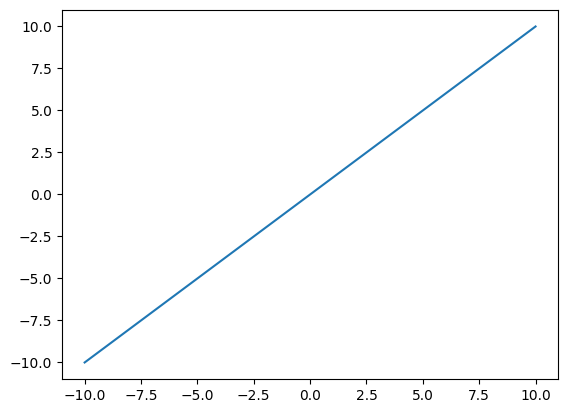

In [65]:
#x=y
import matplotlib.pyplot as plt
x=np.linspace(-10,10,100)
y=x

plt.plot(x,y)


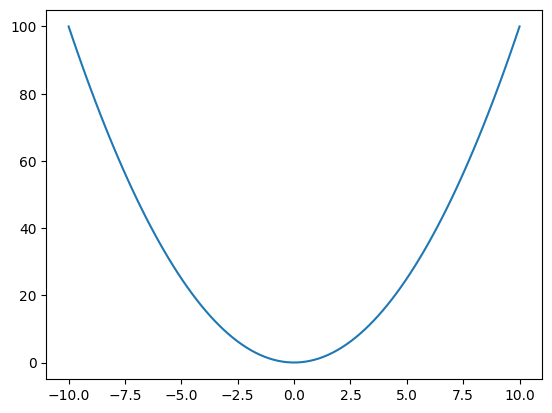

In [66]:
#y=x^2

x =np.linspace(-10,10,100)
y=x**2

plt.plot(x,y)

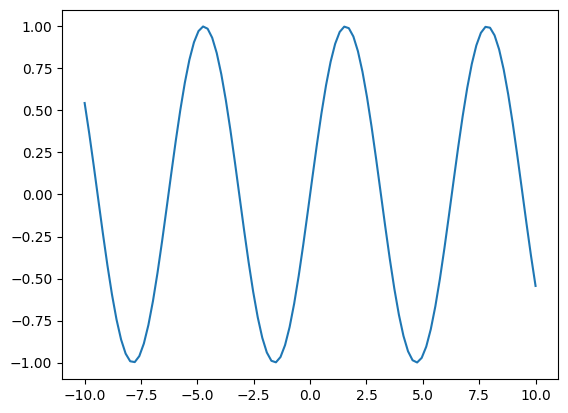

In [67]:
#y=sinx
x =np.linspace(-10,10,100)
y=np.sin(x)

plt.plot(x,y)

C:\Users\Adarsh Patel\AppData\Local\Temp\ipykernel_6352\2385532857.py:3: RuntimeWarning: invalid value encountered in log
  y=x*np.log(x)


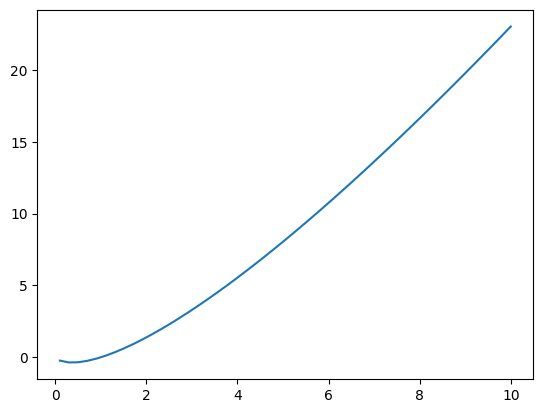

In [70]:
#y= xlog(X)
x =np.linspace(-10,10,100)
y=x*np.log(x)

plt.plot(x,y)

C:\Users\Adarsh Patel\AppData\Local\Temp\ipykernel_6352\2566955269.py:3: RuntimeWarning: invalid value encountered in log
  y=np.log(x)


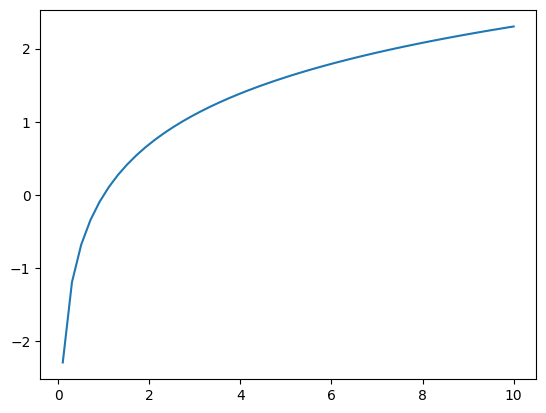

In [71]:
#y= xlog(X)
x =np.linspace(-10,10,100)
y=np.log(x)

plt.plot(x,y)